In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import kv

In [31]:
# ==========================================================
# COSTANTI GENERALI e DATI RIGHE DI IONIZZAZIONE
# ==========================================================
c = 2.99792458e10          # cm/s
G = 6.67430e-8             # cgs
h = 6.62607015e-27         # erg*s
kB = 1.380649e-16          # erg/K
sigma = 5.670374419e-5     # erg cm^-2 s^-1 K^-4
Msun = 1.98847e33          # g

names = np.array(["Ha", "Hb", "Hg", "Hd", "MgII", "CIII", "CIV"])
Eion = np.array([1.89, 2.55, 2.86, 3.02, 15.0, 54.4, 47.9])
nu_ion_list = np.array([4.60e14, 6.20e14, 6.91e14, 7.37e14, 3.63e15, 1.315e16, 1.158e16])

In [32]:
# ==========================================================
# ADAF / RIAF  (codice costruito da Righi)
# ==========================================================
ALFA = 0.3
RMIN = 3.0
RMAX = 1000.0
DELTA = 0.0

C1 = 0.5
C3 = 0.3
TNORM = 1.68e-10

def bessk(n, x):
    return kv(n, x)

def g(teta):
    return (1.0 / bessk(2, 1.0 / teta)) * (2.0 + 2.0 * teta + 1.0 / teta) * np.exp(-1.0 / teta)

def temperat(y, mdot, m, beta):

    ff = y[2]**2
    xm = 1e3 * y[1]**2
    teta = y[0]**2

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm

    # Heating
    q1 = 1.2e4 * g(teta) * ALFA**(-2) * C1**(-2) * C3 * beta * m * mdot**2 / RMIN
    q2 = DELTA * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN
    q = q1 + q2

    # Synchrotron
    nup = s1 * s2 * m**(-0.5) * mdot**0.5 * (teta / TNORM)**2 * RMIN**(-5/4)

    psinc = (
        53.0 * (xm / 1000.0)**3 *
        (teta / (1e9 * TNORM))**7 *
        m**0.5 * mdot**1.5
    )

    # Compton
    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    graffa = ((6.2e7 * (teta / (1e9 * TNORM))) / (nup * 1e-12))**(1 - alfac) - 1
    pcomp = (psinc / 0.71) / (1 - alfac) * graffa

    # Brems
    if teta < 1:
        f = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
    else:
        f = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

    pbrems = 4.78 * ALFA**(-2) * C1**(-2) * np.log(RMAX/RMIN) * f * m * mdot**2

    # Equazioni
    f1 = q - psinc - pcomp - pbrems
    f2 = (1 - ff) * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN - q

    vv = xm**(1/3)
    f3 = (
        vv + 1.852*np.log(vv)
        - 10.36
        - 0.26*np.log(m*mdot)
        + 0.26*np.log(teta**3 * bessk(2, 1/teta))
    )

    return [f1, f3, f2]

def spectrum_adaf(te, f, xm, m, mdot, beta):

    numin = 1e10
    numax = 1e17                                                 #CAMBIARE QUI !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    num = 400

    lnu = np.linspace(np.log10(numin), np.log10(numax), num)
    nu = 10**lnu

    teta = 1.68e-10 * te

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm
    s3 = 1.05e-24

    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    lnup = np.log10(s1 * s2 * m**(-0.5) * mdot**0.5 * te**2 * RMIN**(-5/4))
    lnucmax = np.log10(te) + 10.796

    llsinc = (
        3*np.log10(s1*s2)
        + np.log10(s3)
        - (7/4)*np.log10(RMIN)
        + np.log10(m**0.5 * mdot**1.5)
        + 7*np.log10(te)
    )

    lls = np.zeros(num)
    llc = np.zeros(num)
    llb = np.zeros(num)

    for i in range(num):

        # SYNCHROTRON
        if lnu[i] < lnup:
            lls[i] = (
                np.log10(s3)
                + (8/5)*np.log10(s1*s2)
                + np.log10(m**(6/5) * mdot**(4/5))
                + (21/5)*np.log10(te)
                + (2/5)*lnu[i]
            )
        else:
            lls[i] = 0.0

        # COMPTON
        if lnu[i] > lnup:
            base = llsinc + (alfac - 1)*lnup - alfac*lnu[i]
            cutoff = -(10**(lnu[i] - lnucmax)) / np.log(10)
            llc[i] = base + cutoff
        else:
            llc[i] = 0.0

        # BREMS
        if teta < 1:
            fb = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
        else:
            fb = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

        base_b = (
            24.36
            - 2*np.log10(ALFA*C1)
            + np.log10(np.log(RMAX/RMIN) * fb)
            - np.log10(te)
            + np.log10(m * mdot**2)
        )

        cutoff_b = -(4.8e-11 * nu[i] / te) / np.log(10)
        llb[i] = base_b + cutoff_b

    # questo y è log10(nu * Lnu)
    flux = 10**lls + 10**llc + 10**llb
    y = lnu + np.log10(flux)

    return lnu, y

def specdata_adaf(m, mdot, beta, verbose=False):

    if verbose:
        print(f"ADAF -> m={m}, mdot={mdot}, beta={beta}")

    y0 = [0.5, 1.0, 0.99]
    sol = root(temperat, y0, args=(mdot, m, beta), tol=1e-10)

    if not sol.success:
        print(f"Non converge per mdot={mdot}")

    y = sol.x

    teta = y[0]**2
    te = teta / 1.68e-10
    xm = 1e3 * y[1]**2
    f = y[2]**2

    lnu, log_nuLnu = spectrum_adaf(te, f, xm, m, mdot, beta)

    nu = 10**lnu
    logLnu = log_nuLnu - lnu
    Lnu = 10**logLnu

    return nu, Lnu, log_nuLnu

def calcola_Lion_da_spettro(nu, Lnu, nu_ion):
    mask = nu >= nu_ion
    if np.sum(mask) < 2:
        return 0.0
    return np.trapezoid(Lnu[mask], nu[mask])

In [33]:
# ==========================================================
# SHAKURA-SUNYAEV
# ==========================================================
def spettro_ss(MBH_Msun, mdot_edd, eta=0.083, nu_min=1e13, nu_max=1e17, Nnu=400, Nr=2000):
    """
    MBH_Msun : massa del BH in masse solari
    mdot_edd : tasso di accrescimento in unità di Eddington
    """

    MBH = MBH_Msun * Msun

    # Ledd e Ldisk
    Ledd = 1.3e38 * MBH_Msun           # erg/s
    Ldisk = mdot_edd * Ledd            # assumo lambda_edd = mdot_edd per questo uso
    Mdot = Ldisk / (eta * c**2)        # g/s

    Rs = 2 * G * MBH / c**2
    Rin = 3 * Rs
    Rout = 3000 * Rs

    R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)

    fR = 1.0 - np.sqrt(Rin / R)
    fR = np.clip(fR, 0.0, None)

    T = ((3 * G * MBH * Mdot) / (8 * np.pi * sigma * R**3) * fR)**0.25

    nu = np.logspace(np.log10(nu_min), np.log10(nu_max), Nnu)

    Bnu = np.zeros((Nnu, Nr))

    for j in range(Nr):
        x = h * nu / (kB * T[j])
        x = np.clip(x, 1e-12, 700.0)
        Bnu[:, j] = (2 * h * nu**3 / c**2) / (np.exp(x) - 1.0)

    integrand = R[None, :] * Bnu
    I_nu = np.trapezoid(integrand, R, axis=1)

    Lnu = 4 * np.pi**2 * I_nu
    nuLnu = nu * Lnu

    return nu, Lnu, nuLnu

In [34]:
# ==========================================================
# PARAMETRI DEI DUE MODELLI
# ==========================================================
MBH_common = 1e9      # masse solari
beta_adaf = 0.5

mdot_adaf = [5.7e-3, 0.5e-3, 0.3e-3]
mdot_ss   = [5e-2, 1e-1, 5e-1]

In [35]:
# ==========================================================
# CALCOLO DI L_ion PER TUTTI I CASI
# ==========================================================
risultati = []

# ADAF
for md in mdot_adaf:
    nu, Lnu, nuLnu = specdata_adaf(MBH_common, md, beta_adaf, verbose=False)

    for nome, eion, nu_ion in zip(names, Eion, nu_ion_list):
        Lion = calcola_Lion_da_spettro(nu, Lnu, nu_ion)
        risultati.append({
            "modello": "ADAF",
            "mdot": md,
            "linea": nome,
            "Eion": eion,
            "nu_ion": nu_ion,
            "Lion": Lion
        })

# SS
for md in mdot_ss:
    nu, Lnu, nuLnu = spettro_ss(MBH_common, md)

    for nome, eion, nu_ion in zip(names, Eion, nu_ion_list):
        Lion = calcola_Lion_da_spettro(nu, Lnu, nu_ion)
        risultati.append({
            "modello": "SS",
            "mdot": md,
            "linea": nome,
            "Eion": eion,
            "nu_ion": nu_ion,
            "Lion": Lion
        })

In [36]:
# ==========================================================
# STAMPA TABELLA
# ==========================================================
print("modello   mdot         linea    Eion[eV]    nu_ion[Hz]        Lion[erg/s]")
for r in risultati:
    print(f"{r['modello']:>5s}   {r['mdot']:10.3e}   {r['linea']:>5s}   {r['Eion']:8.2f}   {r['nu_ion']:12.3e}   {r['Lion']:12.3e}")

modello   mdot         linea    Eion[eV]    nu_ion[Hz]        Lion[erg/s]
 ADAF    5.700e-03      Ha       1.89      4.600e+14      3.147e+42
 ADAF    5.700e-03      Hb       2.55      6.200e+14      3.015e+42
 ADAF    5.700e-03      Hg       2.86      6.910e+14      2.981e+42
 ADAF    5.700e-03      Hd       3.02      7.370e+14      2.947e+42
 ADAF    5.700e-03    MgII      15.00      3.630e+15      2.201e+42
 ADAF    5.700e-03    CIII      54.40      1.315e+16      1.457e+42
 ADAF    5.700e-03     CIV      47.90      1.158e+16      1.532e+42
 ADAF    5.000e-04      Ha       1.89      4.600e+14      1.913e+39
 ADAF    5.000e-04      Hb       2.55      6.200e+14      1.601e+39
 ADAF    5.000e-04      Hg       2.86      6.910e+14      1.530e+39
 ADAF    5.000e-04      Hd       3.02      7.370e+14      1.463e+39
 ADAF    5.000e-04    MgII      15.00      3.630e+15      5.813e+38
 ADAF    5.000e-04    CIII      54.40      1.315e+16      2.390e+38
 ADAF    5.000e-04     CIV      47.90     

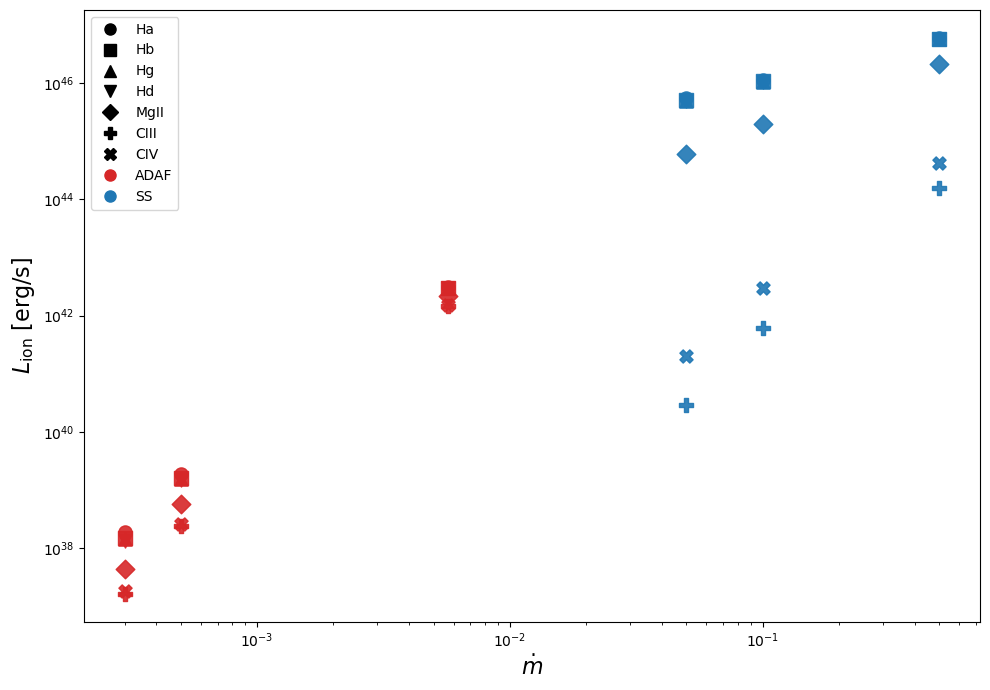

In [37]:
# ==========================================================
# PLOT: x = mdot, y = Lion
# ==========================================================
marker_dict = {
    "Ha": "o",
    "Hb": "s",
    "Hg": "^",
    "Hd": "v",
    "MgII": "D",
    "CIII": "P",
    "CIV": "X"}

color_model = {
    "ADAF": "tab:red",
    "SS": "tab:blue"}

plt.figure(figsize=(10, 7))

for r in risultati:
    plt.scatter(
        r["mdot"],
        r["Lion"],
        marker=marker_dict[r["linea"]],
        color=color_model[r["modello"]],
        s=90,
        alpha=0.9)

# legenda unica
legend_handles = []

# prima le righe: marker diversi, colore nero
for nome in names:
    h = plt.Line2D(
        [0], [0],
        marker=marker_dict[nome],
        color='black',
        linestyle='None',
        markersize=8,
        label=nome)
    legend_handles.append(h)

# poi i modelli: stesso marker, colori diversi
for modello in ["ADAF", "SS"]:
    h = plt.Line2D(
        [0], [0],
        marker='o',
        color=color_model[modello],
        linestyle='None',
        markersize=8,
        label=modello
    )
    legend_handles.append(h)

plt.legend(handles=legend_handles, loc="best", fontsize=10)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\dot m$", fontsize=16)
#plt.xlim(1e-4, 1e-2)
#plt.ylim(7e39, 1e40)
plt.ylabel(r"$L_{\rm ion}$ [erg/s]", fontsize=16)
plt.tight_layout()
plt.show()

OSSERVAZIONE: attenzione a come si pone nu_max sia in SS ma soprattutto in ADAF! Infatti se pongo nu_max in ADAF = 10^20 i punti del grafico vengono tutti attaccati, mentre se pongo 10^17 sono per lo più distinguibili  (CHE COMUNQUE NON SO SE SIA UN BENE E COSA UTILE IN OGNI CASO)
--> QUESTO PERCHE': 